In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df=pd.read_csv('Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.shape

(6704, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df['Age']=df['Age'].astype(int)

<Axes: >

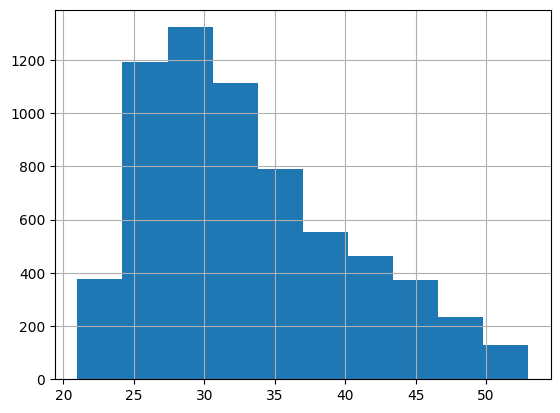

In [18]:
df['Age'].hist()

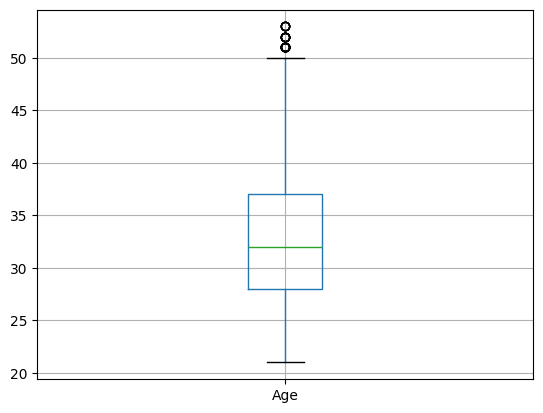

In [15]:
boxplot = df.boxplot(column=['Age'])

In [14]:
def remove_outliers(df):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df = df[(df['Age'] >= lower) & (df['Age'] <= upper)]
    
    return df

In [13]:
df=remove_outliers(df)

In [17]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [19]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['Age'] = pt.fit_transform(df[['Age']])

<Axes: >

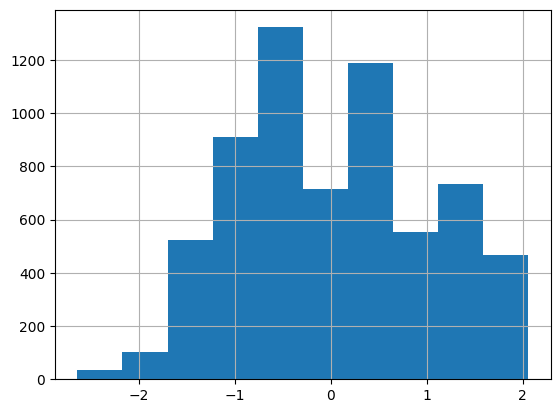

In [20]:
df['Age'].hist()

In [21]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.028684,Male,Bachelor's,Software Engineer,5.0,90000.0
1,-0.702317,Female,Master's,Data Analyst,3.0,65000.0
2,1.508240,Male,PhD,Senior Manager,15.0,150000.0
3,0.597801,Female,Bachelor's,Sales Associate,7.0,60000.0
4,1.997672,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,1.805152,Female,PhD,Director of Marketing,20.0,200000.0
6700,0.028684,Male,High School,Sales Associate,3.0,50000.0
6701,-0.312590,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,1.587338,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [23]:
df['Gender'].value_counts()

Gender
Male      3563
Female    2979
Other        8
Name: count, dtype: int64

In [ ]:
df

SyntaxError: invalid syntax (1872876902.py, line 1)

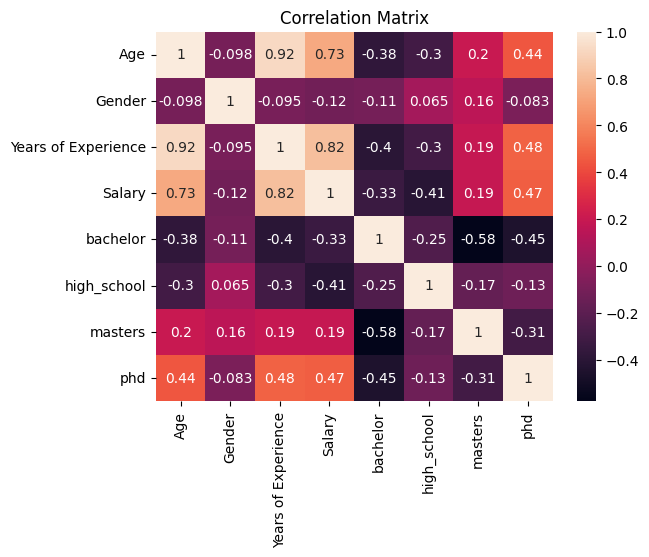

In [50]:

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [27]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

<Axes: xlabel='Gender'>

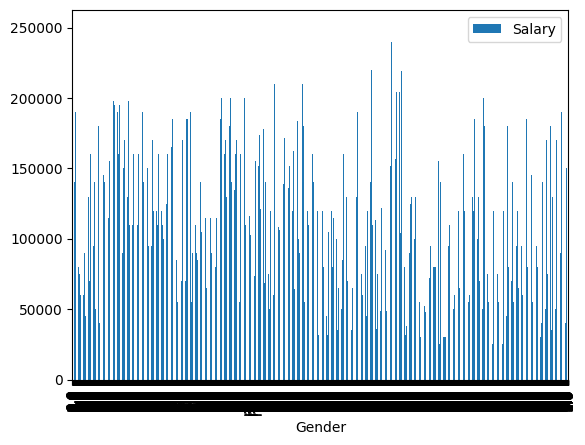

In [31]:
df.plot.bar(x='Gender', y='Salary')

In [32]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.028684,0.0,Bachelor's,Software Engineer,5.0,90000.0
1,-0.702317,1.0,Master's,Data Analyst,3.0,65000.0
2,1.508240,0.0,PhD,Senior Manager,15.0,150000.0
3,0.597801,1.0,Bachelor's,Sales Associate,7.0,60000.0
4,1.997672,0.0,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,1.805152,1.0,PhD,Director of Marketing,20.0,200000.0
6700,0.028684,0.0,High School,Sales Associate,3.0,50000.0
6701,-0.312590,1.0,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,1.587338,0.0,Master's Degree,Marketing Manager,14.0,140000.0


In [33]:
df['Education Level'].value_counts()

Education Level
Bachelor's Degree    2252
Master's Degree      1552
PhD                  1259
Bachelor's            756
High School           442
Master's              288
phD                     1
Name: count, dtype: int64

In [34]:
def clean_education(x):
    x = str(x).strip().lower()
    
    if "phd" in x:
        return "PhD"
    elif "master" in x:
        return "Master's"
    elif "bachelor" in x:
        return "Bachelor's"
    elif "high school" in x:
        return "High School"
    else:
        return x

df['Education Level'] = df['Education Level'].apply(clean_education)

In [35]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.028684,0.0,Bachelor's,Software Engineer,5.0,90000.0
1,-0.702317,1.0,Master's,Data Analyst,3.0,65000.0
2,1.508240,0.0,PhD,Senior Manager,15.0,150000.0
3,0.597801,1.0,Bachelor's,Sales Associate,7.0,60000.0
4,1.997672,0.0,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,1.805152,1.0,PhD,Director of Marketing,20.0,200000.0
6700,0.028684,0.0,High School,Sales Associate,3.0,50000.0
6701,-0.312590,1.0,Bachelor's,Financial Manager,4.0,55000.0
6702,1.587338,0.0,Master's,Marketing Manager,14.0,140000.0


In [36]:
df['Education Level'].value_counts()

Education Level
Bachelor's     3008
Master's       1840
PhD            1260
High School     442
Name: count, dtype: int64

In [37]:
df = pd.get_dummies(df, columns=['Education Level'])

In [38]:
df

,Age,Gender,Job Title,Years of Experience,Salary,Education Level_Bachelor's,Education Level_High School,Education Level_Master's,Education Level_PhD
0,0.028684,0.0,Software Engineer,5.0,90000.0,True,False,False,False
1,-0.702317,1.0,Data Analyst,3.0,65000.0,False,False,True,False
2,1.508240,0.0,Senior Manager,15.0,150000.0,False,False,False,True
3,0.597801,1.0,Sales Associate,7.0,60000.0,True,False,False,False
4,1.997672,0.0,Director,20.0,200000.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...
6699,1.805152,1.0,Director of Marketing,20.0,200000.0,False,False,False,True
6700,0.028684,0.0,Sales Associate,3.0,50000.0,False,True,False,False
6701,-0.312590,1.0,Financial Manager,4.0,55000.0,True,False,False,False
6702,1.587338,0.0,Marketing Manager,14.0,140000.0,False,False,True,False


In [39]:
df = df.rename(columns={
    "Education Level_Bachelor's": "bachelor",
    "Education Level_High School": "high_school",
    "Education Level_Master's": "masters",
    "Education Level_PhD": "phd"
})

df[['bachelor','high_school','masters','phd']] = df[['bachelor','high_school','masters','phd']].astype(int)

In [40]:
df

,Age,Gender,Job Title,Years of Experience,Salary,bachelor,high_school,masters,phd
0,0.028684,0.0,Software Engineer,5.0,90000.0,1,0,0,0
1,-0.702317,1.0,Data Analyst,3.0,65000.0,0,0,1,0
2,1.508240,0.0,Senior Manager,15.0,150000.0,0,0,0,1
3,0.597801,1.0,Sales Associate,7.0,60000.0,1,0,0,0
4,1.997672,0.0,Director,20.0,200000.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
6699,1.805152,1.0,Director of Marketing,20.0,200000.0,0,0,0,1
6700,0.028684,0.0,Sales Associate,3.0,50000.0,0,1,0,0
6701,-0.312590,1.0,Financial Manager,4.0,55000.0,1,0,0,0
6702,1.587338,0.0,Marketing Manager,14.0,140000.0,0,0,1,0


In [47]:
def clean_job(x):
    x = str(x).lower()
    
    if 'engineer' in x or 'developer' in x:
        return 'tech'
    elif 'data' in x:
        return 'data'
    elif 'manager' in x:
        return 'manager'
    elif 'analyst' in x:
        return 'analyst'
    else:
        return 'other'

df['Job Title'] = df['Job Title'].apply(clean_job)

In [48]:
df

,Age,Gender,Job Title,Years of Experience,Salary,bachelor,high_school,masters,phd
0,0.028684,0.0,tech,5.0,90000.0,1,0,0,0
1,-0.702317,1.0,data,3.0,65000.0,0,0,1,0
2,1.508240,0.0,manager,15.0,150000.0,0,0,0,1
3,0.597801,1.0,other,7.0,60000.0,1,0,0,0
4,1.997672,0.0,other,20.0,200000.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
6699,1.805152,1.0,other,20.0,200000.0,0,0,0,1
6700,0.028684,0.0,other,3.0,50000.0,0,1,0,0
6701,-0.312590,1.0,manager,4.0,55000.0,1,0,0,0
6702,1.587338,0.0,manager,14.0,140000.0,0,0,1,0


In [49]:
df['Job Title'].value_counts()

Job Title
tech       2510
other      1463
manager    1381
data        965
analyst     231
Name: count, dtype: int64

In [71]:
d=pd.read_csv('Salary_Data.csv')

In [72]:
d.shape

(6704, 6)

In [73]:
d=d.dropna()

In [74]:
d.shape

(6698, 6)

In [77]:
def remove_outliers(d):
    for col in d.select_dtypes(include=['int64','float64']).columns:
        Q1 = d[col].quantile(0.25)
        Q3 = d[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df = d[(d['Age'] >= lower) & (d['Age'] <= upper)]
    
    return d

In [82]:
d=remove_outliers(d)

In [81]:
d.shape

(6698, 6)

In [80]:
d

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [83]:
d['Gender'] = d['Gender'].map({'Male': 0, 'Female': 1})

In [84]:
d

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,0.0,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,1.0,Master's,Data Analyst,3.0,65000.0
2,45.0,0.0,PhD,Senior Manager,15.0,150000.0
3,36.0,1.0,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,0.0,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,1.0,PhD,Director of Marketing,20.0,200000.0
6700,32.0,0.0,High School,Sales Associate,3.0,50000.0
6701,30.0,1.0,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,0.0,Master's Degree,Marketing Manager,14.0,140000.0
